In [18]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

from thinkbayes import _DictWrapper
import bisect

class Pmf(_DictWrapper):

    def Normalize(self, fraction=1.0):
        if self.log:
            raise ValueError("Pmf is under a log transforms")
        total = self.Total()
        if total == 0.0:
            raise ValueError("total probability is zero")
            return total
        factor = float(fraction)/total
        for x in self.d:
            self.d[x] *=factor
        return total

class Suite(Pmf):
    def Update(self, data):
        for hypo in list(self.Values()):
            like = self.Likelihood(data, hypo)
            self.Mult(hypo, like)
        return self.Normalize()
    
    def MakeCdf(self, name=None):
            return MakeCdfFromPmf(self, name=name)

    def UpdateSet(self, dataset):
        for data in dataset:
            for hypo in self.Values():
                like = self.Likelihood(data, hypo)
                self.Mult(hypo, like)
        return self.Normalize()

def MakeCdfFromPmf(pmf, name=None):
    if name == None:
        name = pmf.name
    return MakeCdfFromItems(pmf.Items(), name)

def MakeCdfFromItems(items, name=''):
    runsum = 0
    xs = []
    cs = []

    for value, count in sorted(items):
        runsum += count
        xs.append(value)
        cs.append(runsum)

    total = float(runsum)
    ps = [c/total for c in cs]
    cdf = Cdf(xs, ps, name)
    return cdf


class Cdf(object):
    def __init__(self, xs=None, ps=None, name=''):
        self.xs = [] if xs is None else xs
        self.ps = [] if ps is None else ps
        self.name = name

    def Value(self,p):
        if p < 0 or p > 1:
            raise ValueError('Probability p must be in range [0, 1]')

        if p == 0: return self.xs[0]
        if p == 1: return self.xs[-1]
        index = bisect.bisect(self.ps, p)
        if p == self.ps[index - 1]:
            return self.xs[index - 1]
        else:
            return self.xs[index]

In [19]:
class Euro(Suite):
    def Likelihood(self, data, hypo):
        x = hypo
        if data == 'H':
            return x/100.0
        else:
            return 1 - x/100.0
        


Text(0.5, 1.0, '一様事前確率でのユーロ硬貨問題に関する事後確率')

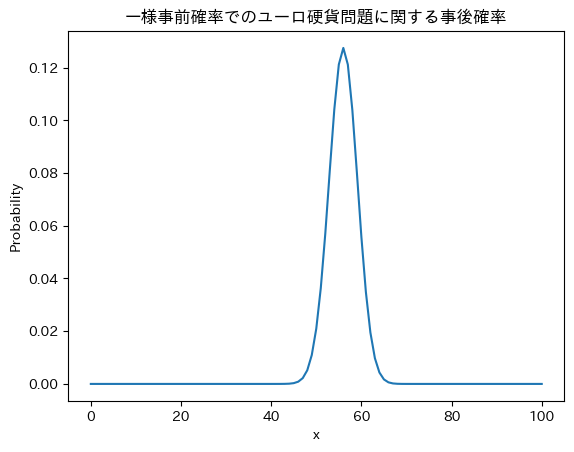

In [20]:
suite = Euro(np.arange(0,101))
dataset = 'H' * 140 + 'T' * 110

for data in dataset:
    suite.Update(data)

xs, ps =zip(*suite.Items())

plt.plot(xs, ps)
plt.xlabel("x")
plt.ylabel("Probability")
plt.title("一様事前確率でのユーロ硬貨問題に関する事後確率")

In [21]:
class Beta(object):
    def __init__(self, alpha=1, beta=1):
        self.alpha = alpha
        self.beta = beta

    def Update(self,data):
        heads, tails = data
        self.alpha += heads
        self.beta += tails

    def Mean(self):
        return float(self.alpha) / (self.alpha + self.beta)

    def EvalPdf(self, x):
        return x**(self.alpha-1) * (1-x)**(self.beta -1)


In [22]:
beta = Beta()
beta.Update((140,110))
beta.Mean()

0.5595238095238095

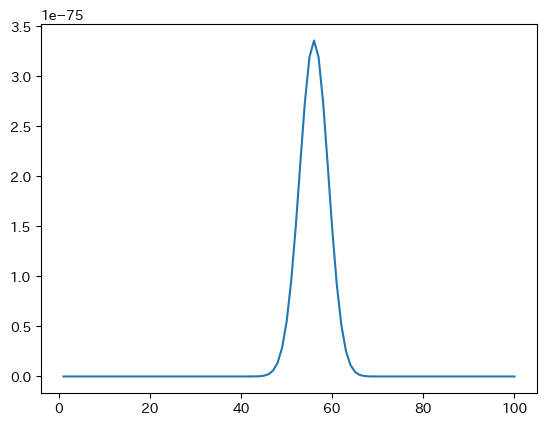

In [33]:
value = []
xs = np.arange(1,101)
for  x in xs:
    value.append(beta.EvalPdf(x/100.0))

plt.plot(xs, value)

In [36]:
def MakePmfFromDict(d, name=''):
    pmf = Pmf(d, name)
    pmf.Normalize()
    return pmf

In [37]:
xs = np.arange(1,101)
probs = [beta.EvalPdf(x/100.0) for x in xs]
pmf = MakePmfFromDict(dict(zip(xs, probs)),"beta")


Text(0.5, 1.0, '一様事前確率でのユーロ硬貨問題に関する事後確率')

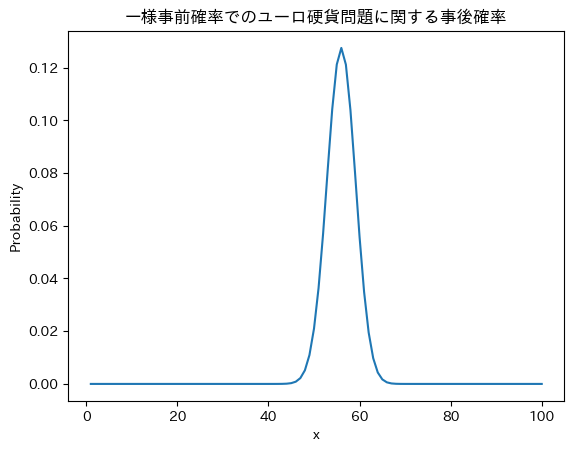

In [40]:
xs, ps =zip(*pmf.Items())

plt.plot(xs, ps)
plt.xlabel("x")
plt.ylabel("Probability")
plt.title("一様事前確率でのユーロ硬貨問題に関する事後確率")